# MPI Sweep — corner reconstruction: 10x10 vs. 33x33 vs. flood

How well do the three approaches reproduce a **concave corner** (vertical fold, the MPI
scene of the simulation) compared with a plain iToF camera under **flood illumination**?
Multipath makes the flood-lit corner bulge into a curve; the dot approaches only see the
direct return of each dot and should keep the kink.

Data: PhaseTrace renders of the `_y` scenes (baseline along y)
- `Schmersal10_y` – 10x10 DOE (`squareLaser`), calibration + MPI set
- `Schmersal30_y` – coherent 33x33 (`laser`), calibration + MPI set
- `Flood_y` – same corner as `Schmersal30_y`, one 110° flood light at the camera, ToF only

Pipeline: the calibration is the unchanged one of `iToF_SL_fusion_pipeline.ipynb`
(Godbaz 4.1/4.2, Agresti), run once per dot pattern on the simulated flat-wall
calibration set. Then every MPI distance (0.5 … 1.5 m) goes through Approach 1/2/3,
exactly like the sweep in `noiseEstimation.ipynb`. All heavy lifting lives in
`dot_calibration.py`, `calibrate.py` and `approaches.py`; this notebook only orchestrates
and plots.

In [1]:
from dot_calibration import DotCalibration
import approaches
import calibrate
import contextlib
import io
import os
import re
import numpy as np
from pathlib import Path
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)   # GPR subpixel fits, harmless

dotCal = DotCalibration()

# ── Data locations (simulation output of run_all_y.sh) ──────────────────────
PBRT_ROOT  = Path("/home/julian/Documents/projects/PBRT")
SIM_OUT    = PBRT_ROOT / "camerasimulationgpu/camerasimulationgpu/output"
MPI_SCENES = PBRT_ROOT / "tof_camerasimulation/test_scenes/Final_Scenes/MPI"   # .pbrt → ground truth

# Dot patterns. cal_blob mirrors the real-camera presets in calibrate.CAMERAS
# (the simulated dots were matched to the real dot sizes: ~15 px vs. ~4 px FWHM).
PATTERNS = {
    "Schmersal10_y": dict(label="10x10",
                          cal_blob=dict(max_sigma=10, num_sigma=10, min_sigma=10, threshold=0.05)),
    "Schmersal30_y": dict(label="33x33",
                          cal_blob=dict(max_sigma=5, num_sigma=10, min_sigma=3, threshold=0.03)),
}
FLOOD = "Flood_y"

# Runtime presets: calibrate.CAMERAS is extended in memory only, calibrate.py is not touched.
for _pat, _p in PATTERNS.items():
    _d = SIM_OUT / _pat / "calibration" / "output"     # SL_*.exr and ToF_*.pcd side by side
    calibrate.CAMERAS[f"Sim_{_pat}"] = dict(sl_cal=_d, tof_cal=_d, K=None, cal_blob=_p["cal_blob"])

SUBPIXEL_MODE          = "GPR"   # paper: LoG + GPR
TRACK_IN_TX_SPACE      = False
BASELINE_OUTLIER_SIGMA = 3.0
MIN_TRACK_POINTS       = 3
TRAIL_Z_MIN            = 0.3     # [m] the corner's side walls come close to the camera

CACHE_DIR   = Path.cwd().parent / "Results" / "mpi_sweep"
CAL_ROOT    = Path.cwd().parent / "Calibrations"
FORCE_RERUN = False              # True → redo calibration and sweep, ignore caches
CACHE_DIR.mkdir(parents=True, exist_ok=True)

approaches.GT_DISTANCE = None    # no single GT distance in a corner scene
print("Setup complete.")

Setup complete.


## Outlier removal

The two other notebooks filter every cloud with CloudCompare's SOR. That filter only
rewrites **binary** PCDs; PhaseTrace writes ASCII, so it would pass every file through
unchanged. It is also not needed here: the simulated ToF film drops near-dark pixels
itself (`minAmplitude 0.003`), which removed the random-depth streaks SOR was fighting.
Everything below runs on the raw clouds.

In [2]:
SOR_TAG = ""   # kept for cache-name compatibility with the other notebooks

## ToF light-path correction

On this rig the ToF is lit by the dot projector itself (VCSEL 5 = 10x10, VCSEL 6 = coherent
33x33), which sits at the baseline **B**, not in the lens centre. The camera nevertheless
converts the phase into a range as if light source and lens coincided: it reports half the
optical path, m = (|P − B| + |P|) / 2, along the pixel ray. With B_z > 0 (projector in
front of the lens) every ToF depth reads short by roughly B_z / 2 — about −8 mm for the
coherent projector, −16 mm for the 10x10 — and the calibration inherits that, because
B and V are fitted to the ToF points.

The correction solves r + |r·d̂ − B| = 2m for the true range r along the pixel ray d̂:

  **r = (4m² − |B|²) / (4m − 2 d̂·B)**,  P_corrected = r · d̂

It wraps `DotCalibration.load_tof_pcd` (after the SOR hook), so the calibration
back-projection and `approaches.common_setup` both see corrected clouds; the files on disk
are untouched. B comes from the calibration itself: the baseline step below starts on the
raw clouds and iterates until B no longer moves. `LIGHT_PATH_CORRECTION = False` restores
the raw behaviour; `LPC_TAG` goes into every calibration / cache name, like `SOR_TAG`.

Here the correction applies to the two dot patterns (their ToF is lit by the projector at
B). The flood scenes are lit from the camera position, so their clouds stay uncorrected
(`TOF_LIGHT_B = None` while they are loaded).

In [3]:
# ── ToF light-path correction (light source at B, not at the lens) ──────────
import contextlib
import io

LIGHT_PATH_CORRECTION = True   # False → raw ToF clouds, as before
LPC_MAX_ITER = 5               # baseline ↔ correction iterations
LPC_TOL      = 1e-4            # [m] stop when B moves less than this
LPC_TAG      = "_lpc" if LIGHT_PATH_CORRECTION else ""
TOF_LIGHT_B  = None            # [m] light source in the PCD frame; set by the baseline step


def correct_light_path(P, B):
    """True points for ToF points P (N, 3) [m] measured with the light source at B."""
    P = np.asarray(P, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)
    with np.errstate(invalid="ignore", divide="ignore"):
        m = np.linalg.norm(P, axis=1)
        d = P / m[:, None]
        r = (4.0 * m * m - B @ B) / (4.0 * m - 2.0 * (d @ B))
    return d * r[:, None]


def _lpc_load_tof_pcd(self, pcd_path, *args, **kwargs):
    t = _lpc_inner_load_tof_pcd(self, pcd_path, *args, **kwargs)
    if TOF_LIGHT_B is None:
        return t
    depth_mode = kwargs.get("depth_mode", args[1] if len(args) > 1 else "radial")
    P = correct_light_path(t["points_3d"], TOF_LIGHT_B)
    t["points_3d"] = P
    t["distance"] = P[:, 2] if depth_mode in ("z", "axial") else np.linalg.norm(P, axis=1)
    if "points_map" in t:
        H, W = t["points_map"].shape[:2]
        t["points_map"] = P.reshape(H, W, 3)
        t["depth_map"] = t["distance"].reshape(H, W)
    return t


_lpc_load_tof_pcd._is_lpc = True
# Wrap whatever load_tof_pcd currently is (the SOR hook, if that cell ran) — but never
# wrap ourselves when this cell is executed twice.
if not getattr(DotCalibration.load_tof_pcd, "_is_lpc", False):
    _lpc_inner_load_tof_pcd = DotCalibration.load_tof_pcd
DotCalibration.load_tof_pcd = _lpc_load_tof_pcd

print("Light-path correction " + ("ON — B is estimated iteratively in the baseline step"
                                  if LIGHT_PATH_CORRECTION else "OFF — raw ToF clouds")
      + f"   (tag '{LPC_TAG}')")


def light_origin(pat):
    # Light source the calibration of `pat` was corrected with (None = at the camera).
    o = CALS[pat].get("metadata", {}).get("tof_light_origin")
    return None if o is None else np.asarray(o, dtype=float)

Light-path correction ON — B is estimated iteratively in the baseline step   (tag '_lpc')


## Camera matrix from the simulated geometry

The scenes use `fovX 67°, fovY 51°` at 640×480. Instead of trusting the field-of-view
convention, K is fitted directly from a dense cloud (flood at 1 m, every pixel valid):
for every pixel u = f_x·x/z + c_x and v = f_y·y/z + c_y. The sign of f_y comes out
negative because PhaseTrace's y axis points up.

In [4]:
def fit_K_from_pcd(pcd_path):
    t = dotCal.load_tof_pcd(str(pcd_path), unit_scale=0.001, depth_mode="axial")
    P = t["points_map"]
    H, W = P.shape[:2]
    v, u = np.mgrid[0:H, 0:W]
    ok = np.isfinite(P).all(axis=-1)
    x, y, z = P[..., 0][ok], P[..., 1][ok], P[..., 2][ok]
    (fx, cx), *_ = np.linalg.lstsq(np.c_[x / z, np.ones_like(x)], u[ok], rcond=None)
    (fy, cy), *_ = np.linalg.lstsq(np.c_[y / z, np.ones_like(y)], v[ok], rcond=None)
    res_u = u[ok] - (fx * x / z + cx)
    res_v = v[ok] - (fy * y / z + cy)
    return np.array([[fx, 0.0, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]]), res_u, res_v, int(ok.sum())

K_PCD = SIM_OUT / FLOOD / "mpi" / "output" / "ToF_MPI_1m_Flood.pcd"
K, _ru, _rv, _n = fit_K_from_pcd(K_PCD)
K_inv = np.linalg.inv(K)
fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]
print(f"K from {_n} pixels of {K_PCD.name}:")
print(np.array2string(K, precision=3, suppress_small=True))
print(f"residual |u| p99 = {np.percentile(np.abs(_ru), 99):.3f} px, |v| p99 = {np.percentile(np.abs(_rv), 99):.3f} px")
print(f"check: 240 / tan(51°/2) = {240 / np.tan(np.radians(25.5)):.1f}  "
      f"(pbrt applies fovY to the shorter axis, square pixels)")
for _pat in PATTERNS:
    calibrate.CAMERAS[f"Sim_{_pat}"]["K"] = K

K from 307200 pixels of ToF_MPI_1m_Flood.pcd:
[[ 503.17    0.    320.  ]
 [   0.   -503.17  240.  ]
 [   0.      0.      1.  ]]
residual |u| p99 = 0.001 px, |v| p99 = 0.001 px
check: 240 / tan(51°/2) = 503.2  (pbrt applies fovY to the shorter axis, square pixels)


## Calibration Steps 1–6 (per dot pattern)

Identical to `iToF_SL_fusion_pipeline.ipynb`, wrapped in a function so that both
patterns go through the same code:

1. LoG blob detection + GPR subpixel localisation on every calibration SL image
2. Cross-distance NN tracking → stable dot IDs; X/Y travel mode + baseline guess
3. Back-projection of every detection with the iToF depth
4. Baseline B (LS intersection of the dot lines, outlier rays removed)
5. Unit vectors V_i
6. 1-D dot trails (affine in w = 1/z) + σ_u, σ_u_ab, σ_ToF(z)

The result is saved as `Calibrations/Sim_<pattern>_mpisweep/calibration.json` and reused
on the next run unless `FORCE_RERUN = True`.

Known artefact: the coherent pattern's real calibration (from which the simulated
dot directions were taken) contains one duplicated track at the right image edge
(JSON id 1115 sits 0.47° next to id 1104). In the simulation the two dots overlap.

Schmersal10_y: calibration distances [0.4, 0.44444, 0.5, 0.57143, 0.66666, 0.8, 1.0, 1.33333, 2.0, 4.0]


  dots per distance: [90, 90, 92, 93, 95, 96, 97, 96, 95, 96]
  travel mode y, B_guess = [0.00071 0.03756 0.03253]
  tracked roster: 100 dots


  baseline from 92 lines: B = [0.00071 0.03651 0.03186]  (AB 3.651 cm)


  LPC iteration 1: B = [ 0.73 37.55 32.53] mm   |ΔB| = 1.231 mm


  LPC iteration 2: B = [ 0.72 37.57 32.56] mm   |ΔB| = 0.039 mm
  unit vectors: 98 / 100


  trails: 98, σ_u = 0.0214 px, σ_u_ab = 0.0937 px
  σ_ToF(z): 0.40 m → 3.6 mm, 0.44 m → 3.7 mm, 0.50 m → 4.5 mm, 0.57 m → 4.4 mm, 0.67 m → 5.1 mm, 0.80 m → 6.6 mm, 1.00 m → 7.0 mm, 1.33 m → 11.0 mm, 2.00 m → 18.4 mm, 4.00 m → 40.0 mm


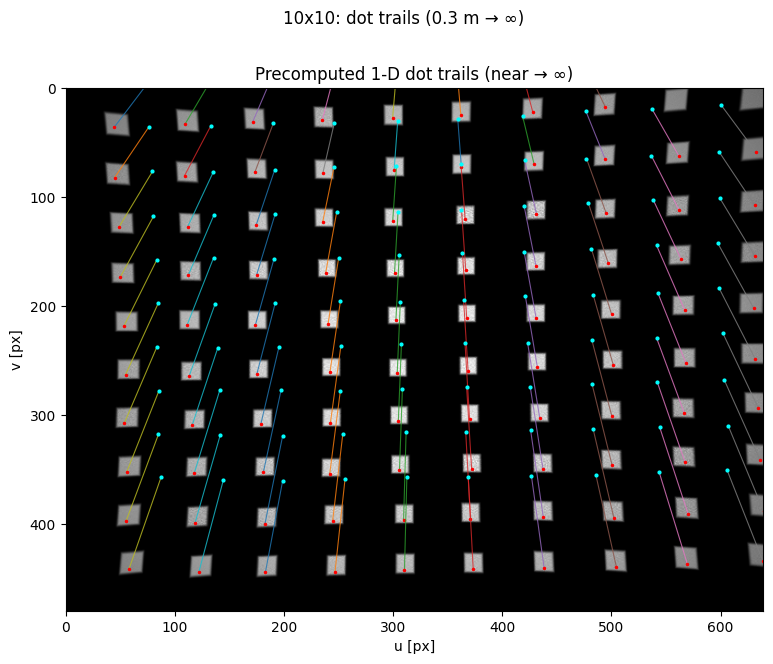

  saved → /home/julian/Documents/Github/iToF-SL-Combination/Calibrations/Sim_Schmersal10_y_lpc_mpisweep/calibration.json
Schmersal30_y: calibration distances [0.4, 0.44444, 0.5, 0.57143, 0.66666, 0.8, 1.0, 1.33333, 2.0, 4.0]


  dots per distance: [1032, 1051, 1058, 1060, 1073, 1073, 1073, 1067, 1047, 1048]
  travel mode y, B_guess = [-0.02143  0.04101  0.01664]
  tracked roster: 1098 dots


  baseline from 1055 lines: B = [-0.02114  0.04037  0.01707]  (AB 4.037 cm)


  LPC iteration 1: B = [-21.44  41.02  16.66] mm   |ΔB| = 0.828 mm


  LPC iteration 2: B = [-21.44  41.01  16.64] mm   |ΔB| = 0.019 mm


  unit vectors: 1093 / 1098


  trails: 1093, σ_u = 0.0236 px, σ_u_ab = 0.0715 px
  σ_ToF(z): 0.40 m → 4.3 mm, 0.44 m → 4.9 mm, 0.50 m → 5.7 mm, 0.57 m → 6.7 mm, 0.67 m → 7.3 mm, 0.80 m → 9.2 mm, 1.00 m → 11.5 mm, 1.33 m → 14.9 mm, 2.00 m → 21.0 mm, 4.00 m → 46.9 mm


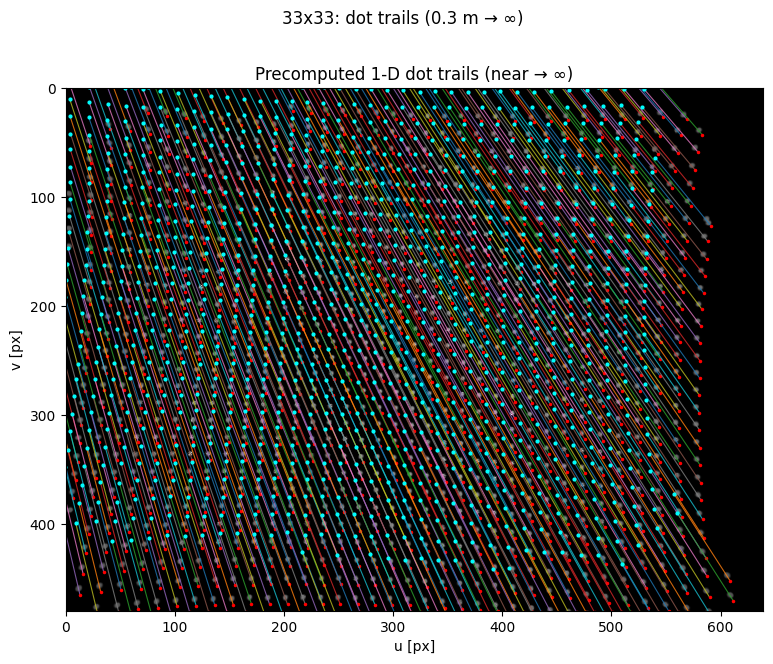

  saved → /home/julian/Documents/Github/iToF-SL-Combination/Calibrations/Sim_Schmersal30_y_lpc_mpisweep/calibration.json
Schmersal10_y: ToF light origin = [0.72, 37.57, 32.56] mm
Schmersal30_y: ToF light origin = [-21.44, 41.01, 16.64] mm


In [5]:
import json as _json
from datetime import datetime as _dt


def calibrate_pattern(pat):
    cam = f"Sim_{pat}"
    cfg = calibrate.CAMERAS[cam]
    global TOF_LIGHT_B
    TOF_LIGHT_B = None                                   # first pass on the raw clouds
    cal_file = CAL_ROOT / f"{cam}{LPC_TAG}_mpisweep" / "calibration.json"
    if cal_file.exists() and not FORCE_RERUN:
        cal = approaches.load_calibration(str(cal_file))
        cal["K"], cal["K_inv"] = np.asarray(cal["K"]), np.asarray(cal["K_inv"])
        print(f"{pat}: calibration loaded from {cal_file}")
        return cal

    # ── Steps 1+2: detection, subpixel, tracking ────────────────────────────
    tof_paths = sorted(cfg["tof_cal"].glob("ToF_*m.pcd"),
                       key=lambda p: calibrate.distance_for(cfg, dotCal, p))
    tof_paths = [str(p) for p in tof_paths]
    cal_dists = [calibrate.distance_for(cfg, dotCal, p) for p in tof_paths]
    print(f"{pat}: calibration distances {cal_dists}")
    subpixel_list_unordered, image = [], None
    for tof_p in tof_paths:
        sl_p = calibrate.find_sl_image(cfg["sl_cal"], Path(tof_p).name)
        blobs, image = dotCal.detect_blobs(str(sl_p), visualize=False, **cfg["cal_blob"])
        _, subpixels = dotCal.detect_subpixel_locations(blobs, image, mode=SUBPIXEL_MODE)
        subpixel_list_unordered.append(subpixels)
    print(f"  dots per distance: {[len(s) for s in subpixel_list_unordered]}")
    subpixel_list = dotCal.track_dots_across_distances(
        subpixel_list_unordered, ref_idx=0, threshold_factor=0.5)

    mode_info = dotCal.detect_travel_mode(subpixel_list, cal_dists, K)
    mode, B_guess_vec = mode_info["mode"], mode_info["B_guess_vec"]
    print(f"  travel mode {mode}, B_guess = {np.round(B_guess_vec, 5)}")
    if TRACK_IN_TX_SPACE:
        coords_list = dotCal.tx_space_coords(subpixel_list_unordered, tof_paths, K=K,
                                             baseline_guess=B_guess_vec)
        subpixel_list = dotCal.track_dots_across_distances(
            subpixel_list_unordered, ref_idx=0, threshold_factor=0.5,
            coords_list=coords_list, travel_mode=mode)
    n_dots = max(int(d["id"]) for spx in subpixel_list for d in spx) + 1
    print(f"  tracked roster: {n_dots} dots")

    # ── Steps 3–5: back-projection, baseline, unit vectors ──────────────────
    U, U_tx = dotCal.backproject_calibration_dots(
        subpixel_list, tof_paths, K=K, pcd_depth_mode="radial",
        baseline_guess=B_guess_vec, tof_sample=cfg.get("tof_sample"))
    intersection, n_lines = dotCal.estimate_baseline(
        U_tx, outlier_sigma=BASELINE_OUTLIER_SIGMA, min_points=MIN_TRACK_POINTS)
    B = B_guess_vec + intersection
    AB = float(B[0 if mode == "x" else 1])
    print(f"  baseline from {n_lines} lines: B = {np.round(B, 5)}  (AB {AB * 100:.3f} cm)")
    if LIGHT_PATH_CORRECTION:          # re-run back-projection + baseline with the light at B
        for it in range(1, LPC_MAX_ITER + 1):
            TOF_LIGHT_B = B.copy()
            with contextlib.redirect_stdout(io.StringIO()):
                U, U_tx = dotCal.backproject_calibration_dots(
                    subpixel_list, tof_paths, K=K, pcd_depth_mode="radial",
                    baseline_guess=B_guess_vec, tof_sample=cfg.get("tof_sample"))
            intersection, n_lines = dotCal.estimate_baseline(
                U_tx, outlier_sigma=BASELINE_OUTLIER_SIGMA, min_points=MIN_TRACK_POINTS)
            B_new = B_guess_vec + intersection
            dB = float(np.linalg.norm(B_new - B))
            print(f"  LPC iteration {it}: B = {np.round(B_new * 1e3, 2)} mm   |ΔB| = {dB * 1e3:.3f} mm")
            B = B_new
            if dB < LPC_TOL:
                break
        TOF_LIGHT_B = B.copy()
        AB = float(B[0 if mode == "x" else 1])
    V = dotCal.estimate_unit_vectors(U, B)
    print(f"  unit vectors: {int(np.all(np.isfinite(V), axis=1).sum())} / {len(V)}")

    # ── Step 6: trails + noise estimates ────────────────────────────────────
    image_shape = image.shape[:2]
    trails = dotCal.fit_trails_from_detections(
        subpixel_list, U, z_min=TRAIL_Z_MIN, step_px=1.0, image_shape=image_shape, V=V, B=B, K=K)
    sigma_u = dotCal.estimate_sigma_u_trails(subpixel_list, trails)
    sigma_tof_table = dotCal.estimate_sigma_tof(U, expected_z=cal_dists)
    sl_paths = [calibrate.find_sl_image(cfg["sl_cal"], Path(p).name) for p in tof_paths]
    sigma_u_ab = calibrate.estimate_sigma_u_ab(dotCal, subpixel_list, trails, sl_paths, TRAIL_Z_MIN)
    print(f"  trails: {sum(t is not None for t in trails)}, σ_u = {sigma_u:.4f} px, "
          f"σ_u_ab = {sigma_u_ab:.4f} px")
    print("  σ_ToF(z): " + ", ".join(f"{z:.2f} m → {s * 1e3:.1f} mm" for z, s in sigma_tof_table))

    fig = dotCal.plot_dot_trails(trails, image_shape=image_shape, background=image)
    fig.suptitle(f"{PATTERNS[pat]['label']}: dot trails ({TRAIL_Z_MIN} m → ∞)")
    plt.show()

    cal = {
        "K": K, "K_inv": K_inv, "V": V, "B": B, "AB": AB, "mode": mode,
        "U": U, "cal_dists": [float(d) for d in cal_dists],
        "subpixel_list": subpixel_list, "trails": trails,
        "sigma_u": float(sigma_u), "sigma_u_ab": float(sigma_u_ab),
        "sigma_tof_table": sigma_tof_table,
        "metadata": {"pcd_unit_scale": 0.001, "trail_z_min": TRAIL_Z_MIN, "mode": mode,
                     "tof_light_origin": None if TOF_LIGHT_B is None else np.asarray(TOF_LIGHT_B).tolist()},
    }
    cal_file.parent.mkdir(parents=True, exist_ok=True)
    with open(cal_file, "w") as f:
        _json.dump(calibrate.sanitize({
            **{k: v for k, v in cal.items() if k != "trails"},
            "trails": [None if t is None else
                       {"u": t["u"].tolist(), "v": t["v"].tolist(), "w": t["w"].tolist()}
                       for t in trails],
            "metadata": {**cal["metadata"], "created": _dt.now().isoformat(),
                         "camera": cam, "pipeline": "codePaperlike/MPIsweep",
                         "subpixel_mode": SUBPIXEL_MODE, "pcd_depth_mode": "radial"},
        }), f)
    print(f"  saved → {cal_file}")
    TOF_LIGHT_B = None
    return cal


CALS = {pat: calibrate_pattern(pat) for pat in PATTERNS}
for pat in PATTERNS:
    print(f"{pat}: ToF light origin = "
          f"{'camera (no correction)' if light_origin(pat) is None else np.round(light_origin(pat) * 1e3, 2).tolist()}"
          f"{'' if light_origin(pat) is None else ' mm'}")

## Ground truth: the corner

Each MPI scene file holds the corner as a triangle mesh with six vertices: the left
wall from (x_left, z_front) to the fold (x_fold, d) and the right wall from the fold to
(x_right, z_front); both walls are vertical (y = ±10 m). The fold is vertical, so the
corner is fully described by a polyline in the x–z plane (top view).

The 10x10 corner has its fold on the central dot column (x_fold ≠ 0); the 33x33 and the
flood corner have it at x = 0. Whether the x axes of PCD and scene file agree is checked
on the raw 33x33 ToF cloud (dot pixels only): direct returns, hardly any multipath. The
flood cloud is no use for this check, multipath shifts it by ~10 cm.

In [6]:
def mpi_files(series):
    # (distance [m], scene .pbrt, SL .exr or None, ToF .pcd) per MPI distance.
    if series == FLOOD:
        scene_dir, sl_dir = MPI_SCENES / "ToF" / FLOOD, None
        tag = "Flood"
    else:
        scene_dir, sl_dir = MPI_SCENES / "ToF" / series, SIM_OUT / series / "mpi" / "output"
        tag = "Schm"
    out_dir = SIM_OUT / series / "mpi" / "output"
    rows = []
    for scene in scene_dir.glob(f"ToF_MPI_*m_{tag}.pbrt"):
        d = dotCal.parse_distance_from_name(scene.name)
        sl = None if sl_dir is None else sl_dir / scene.name.replace("ToF_MPI_", "SL_MPI_").replace(".pbrt", ".exr")
        rows.append((d, scene, sl, out_dir / scene.name.replace(".pbrt", ".pcd")))
    return sorted(rows)


def parse_corner(scene_path):
    # Corner polyline [(x_left, z_front), (x_fold, d), (x_right, z_front)] from the mesh.
    txt = Path(scene_path).read_text()
    block = re.search(r'"point3 P" \[(.*?)\]', txt[txt.index("WorldBegin"):], re.S).group(1)
    P = np.array(block.split(), float).reshape(-1, 3)
    xz = np.unique(P[:, [0, 2]].round(6), axis=0)          # 3 distinct (x, z) pairs
    fold = xz[np.argmax(xz[:, 1])]
    ends = xz[xz[:, 1] < fold[1]]
    left, right = ends[np.argmin(ends[:, 0])], ends[np.argmax(ends[:, 0])]
    return np.array([left, fold, right])


X_SIGN = 1.0   # set below after checking the flood cloud


def corner_of(scene_path):
    c = parse_corner(scene_path).copy()
    c[:, 0] *= X_SIGN
    return c[np.argsort(c[:, 0])]


def z_gt(x, corner):
    # GT depth of the corner at lateral position x (single-valued over the corner width).
    return np.interp(x, corner[:, 0], corner[:, 1], left=np.nan, right=np.nan)


def dist_to_gt(x, z, corner):
    # Perpendicular distance [m] of points (x, z) to the nearer of the two walls.
    pts = np.c_[x, z]
    best = np.full(len(pts), np.inf)
    for a, b in ((corner[0], corner[1]), (corner[1], corner[2])):
        ab = b - a
        t = np.clip(((pts - a) @ ab) / (ab @ ab), 0, 1)
        best = np.minimum(best, np.linalg.norm(pts - (a + t[:, None] * ab), axis=1))
    return best


def load_cloud(pcd_path):
    t = dotCal.load_tof_pcd(str(pcd_path), unit_scale=0.001, depth_mode="axial")
    P = t["points_map"].reshape(-1, 3)
    return P[np.isfinite(P).all(axis=1)]


# x-axis check on the 33x33 dot pixels at 1 m: which sign puts the walls on the GT?
_d, _scene, _, _pcd = [r for r in mpi_files("Schmersal30_y") if abs(r[0] - 1.0) < 1e-6][0]
TOF_LIGHT_B = light_origin("Schmersal30_y")
_t = dotCal.load_tof_pcd(str(_pcd), unit_scale=0.001, depth_mode="axial")
TOF_LIGHT_B = None
_g = _t["intensity"]
_cl = _t["points_3d"][np.isfinite(_t["points_3d"]).all(axis=1) & (_g > 0.3 * np.nanpercentile(_g, 99.9))]
_res = {}
for s in (1.0, -1.0):
    X_SIGN = s
    _res[s] = np.median(dist_to_gt(_cl[:, 0], _cl[:, 2], corner_of(_scene)))
X_SIGN = min(_res, key=_res.get)
print(f"median distance 33x33 dot pixels → GT: x as is {_res[1.0] * 1e3:.1f} mm, "
      f"x mirrored {_res[-1.0] * 1e3:.1f} mm  →  X_SIGN = {X_SIGN:+.0f}")
for series in list(PATTERNS) + [FLOOD]:
    print(f"{series:14s}: {len(mpi_files(series))} distances, corner at 1 m = "
          f"{np.round(corner_of([r for r in mpi_files(series) if abs(r[0] - 1) < 1e-6][0][1]), 3).tolist()}")

median distance 33x33 dot pixels → GT: x as is 9.6 mm, x mirrored 126.6 mm  →  X_SIGN = +1
Schmersal10_y : 11 distances, corner at 1 m = [[-0.492, 0.2], [-0.029, 1.0], [0.851, 0.2]]
Schmersal30_y : 11 distances, corner at 1 m = [[-0.462, 0.2], [0.0, 1.0], [0.88, 0.2]]
Flood_y       : 11 distances, corner at 1 m = [[-0.462, 0.2], [0.0, 1.0], [0.88, 0.2]]


## Sweep: Approach 1/2/3 on every MPI distance

Per (pattern, distance): one `common_setup` (SL EXR + ToF PCD) feeds all three runners,
exactly like `_run_frame` in `noiseEstimation.ipynb`. Each valid dot becomes a 3-D point
from its pixel position and depth:

| | depth | pixel |
|---|---|---|
| Approach 1 – consistency error | `Z_out` (ToF at min ε) | `u_out, v_out` |
| Approach 2 – ML fusion | `z_fus` | `u_sub, v_sub` |
| Approach 3 – active brightness | `Z_out` (triangulated) | `u_sub, v_sub` |

X = (u − c_x)/f_x · Z (axial depth). The flood series is the raw iToF cloud; there is no
SL image, so the approaches do not apply. Results are cached per (series, distance)
in `Results/mpi_sweep/`.

In [7]:
APPROACH_KEYS = {1: ("Z_out", "u_out", "v_out"), 2: ("z_fus", "u_sub", "v_sub"), 3: ("Z_out", "u_sub", "v_sub")}


def to_xyz(results, zkey, ukey, vkey):
    rows = [(r[ukey], r[vkey], r[zkey]) for r in results
            if np.isfinite(r.get(zkey, np.nan)) and np.isfinite(r.get(ukey, np.nan))]
    if not rows:
        return np.zeros((0, 3))
    u, v, z = np.array(rows, float).T
    return np.c_[(u - cx) / fx * z, (v - cy) / fy * z, z]


def run_dots(pat, d, sl_p, tof_p):
    global TOF_LIGHT_B
    cache = CACHE_DIR / f"{pat}_{d:.2f}m{SOR_TAG}{LPC_TAG}.npz"
    if cache.exists() and not FORCE_RERUN:
        with np.load(cache) as f:
            return {a: f[f"A{a}"] for a in (1, 2, 3)} | {"n_trails": int(f["n_trails"])}
    cal = CALS[pat]
    TOF_LIGHT_B = light_origin(pat)               # same correction as in the calibration
    with contextlib.redirect_stdout(io.StringIO()):
        setup = approaches.common_setup(dotCal, cal, str(sl_p), str(tof_p))
        res = {1: approaches.run_approach_1(dotCal, cal, setup, make_plots=False),
               2: approaches.run_approach_2(dotCal, cal, setup, make_plots=False),
               3: approaches.run_approach_3(dotCal, cal, setup, make_plots=False)}
    out = {a: to_xyz(res[a]["results"], *APPROACH_KEYS[a]) for a in (1, 2, 3)}
    out["n_trails"] = sum(t is not None for t in setup["trails"])
    np.savez_compressed(cache, **{f"A{a}": out[a] for a in (1, 2, 3)}, n_trails=out["n_trails"])
    return out


SWEEP = {}      # (series, approach or "ToF") → {distance: (N, 3) points}
CORNERS = {}    # (series, distance) → corner polyline
N_TRAILS = {}
for pat in PATTERNS:
    for d, scene, sl_p, tof_p in mpi_files(pat):
        r = run_dots(pat, d, sl_p, tof_p)
        CORNERS[(pat, d)] = corner_of(scene)
        N_TRAILS[pat] = r["n_trails"]
        for a in (1, 2, 3):
            SWEEP.setdefault((pat, a), {})[d] = r[a]
        print(f"{pat} {d:.1f} m: valid dots A1/A2/A3 = "
              f"{len(r[1])}/{len(r[2])}/{len(r[3])} of {r['n_trails']} trails")
TOF_LIGHT_B = None                                # flood light sits at the camera
for d, scene, _, tof_p in mpi_files(FLOOD):
    CORNERS[(FLOOD, d)] = corner_of(scene)
    SWEEP.setdefault((FLOOD, "ToF"), {})[d] = load_cloud(tof_p)
DISTS = sorted(SWEEP[(FLOOD, "ToF")])
print(f"flood: {len(DISTS)} clouds, {np.mean([len(c) for c in SWEEP[(FLOOD, 'ToF')].values()]):.0f} points each")

Schmersal10_y 0.5 m: valid dots A1/A2/A3 = 95/62/62 of 98 trails


Schmersal10_y 0.6 m: valid dots A1/A2/A3 = 96/90/90 of 98 trails


Schmersal10_y 0.7 m: valid dots A1/A2/A3 = 97/96/96 of 98 trails


Schmersal10_y 0.8 m: valid dots A1/A2/A3 = 97/96/96 of 98 trails


Schmersal10_y 0.9 m: valid dots A1/A2/A3 = 98/97/97 of 98 trails


...

Schmersal30_y 1.2 m: valid dots A1/A2/A3 = 1076/1075/1075 of 1093 trails


Schmersal30_y 1.3 m: valid dots A1/A2/A3 = 1076/1074/1074 of 1093 trails


Schmersal30_y 1.4 m: valid dots A1/A2/A3 = 1075/1074/1074 of 1093 trails


Schmersal30_y 1.5 m: valid dots A1/A2/A3 = 1074/1071/1071 of 1093 trails


flood: 11 clouds, 307200 points each


## Result 1 — top view of the corner, all approaches × all illuminations

One row per distance, seven columns side by side: 10x10 A1 | A2 | A3, 33x33 A1 | A2 | A3,
flood (iToF only). Black line: ground-truth corner. The title gives the RMSE of the
perpendicular distance to the GT walls and the number of points. All panels in a row share
the axes, so a rounded corner or a bias is directly comparable across the row.

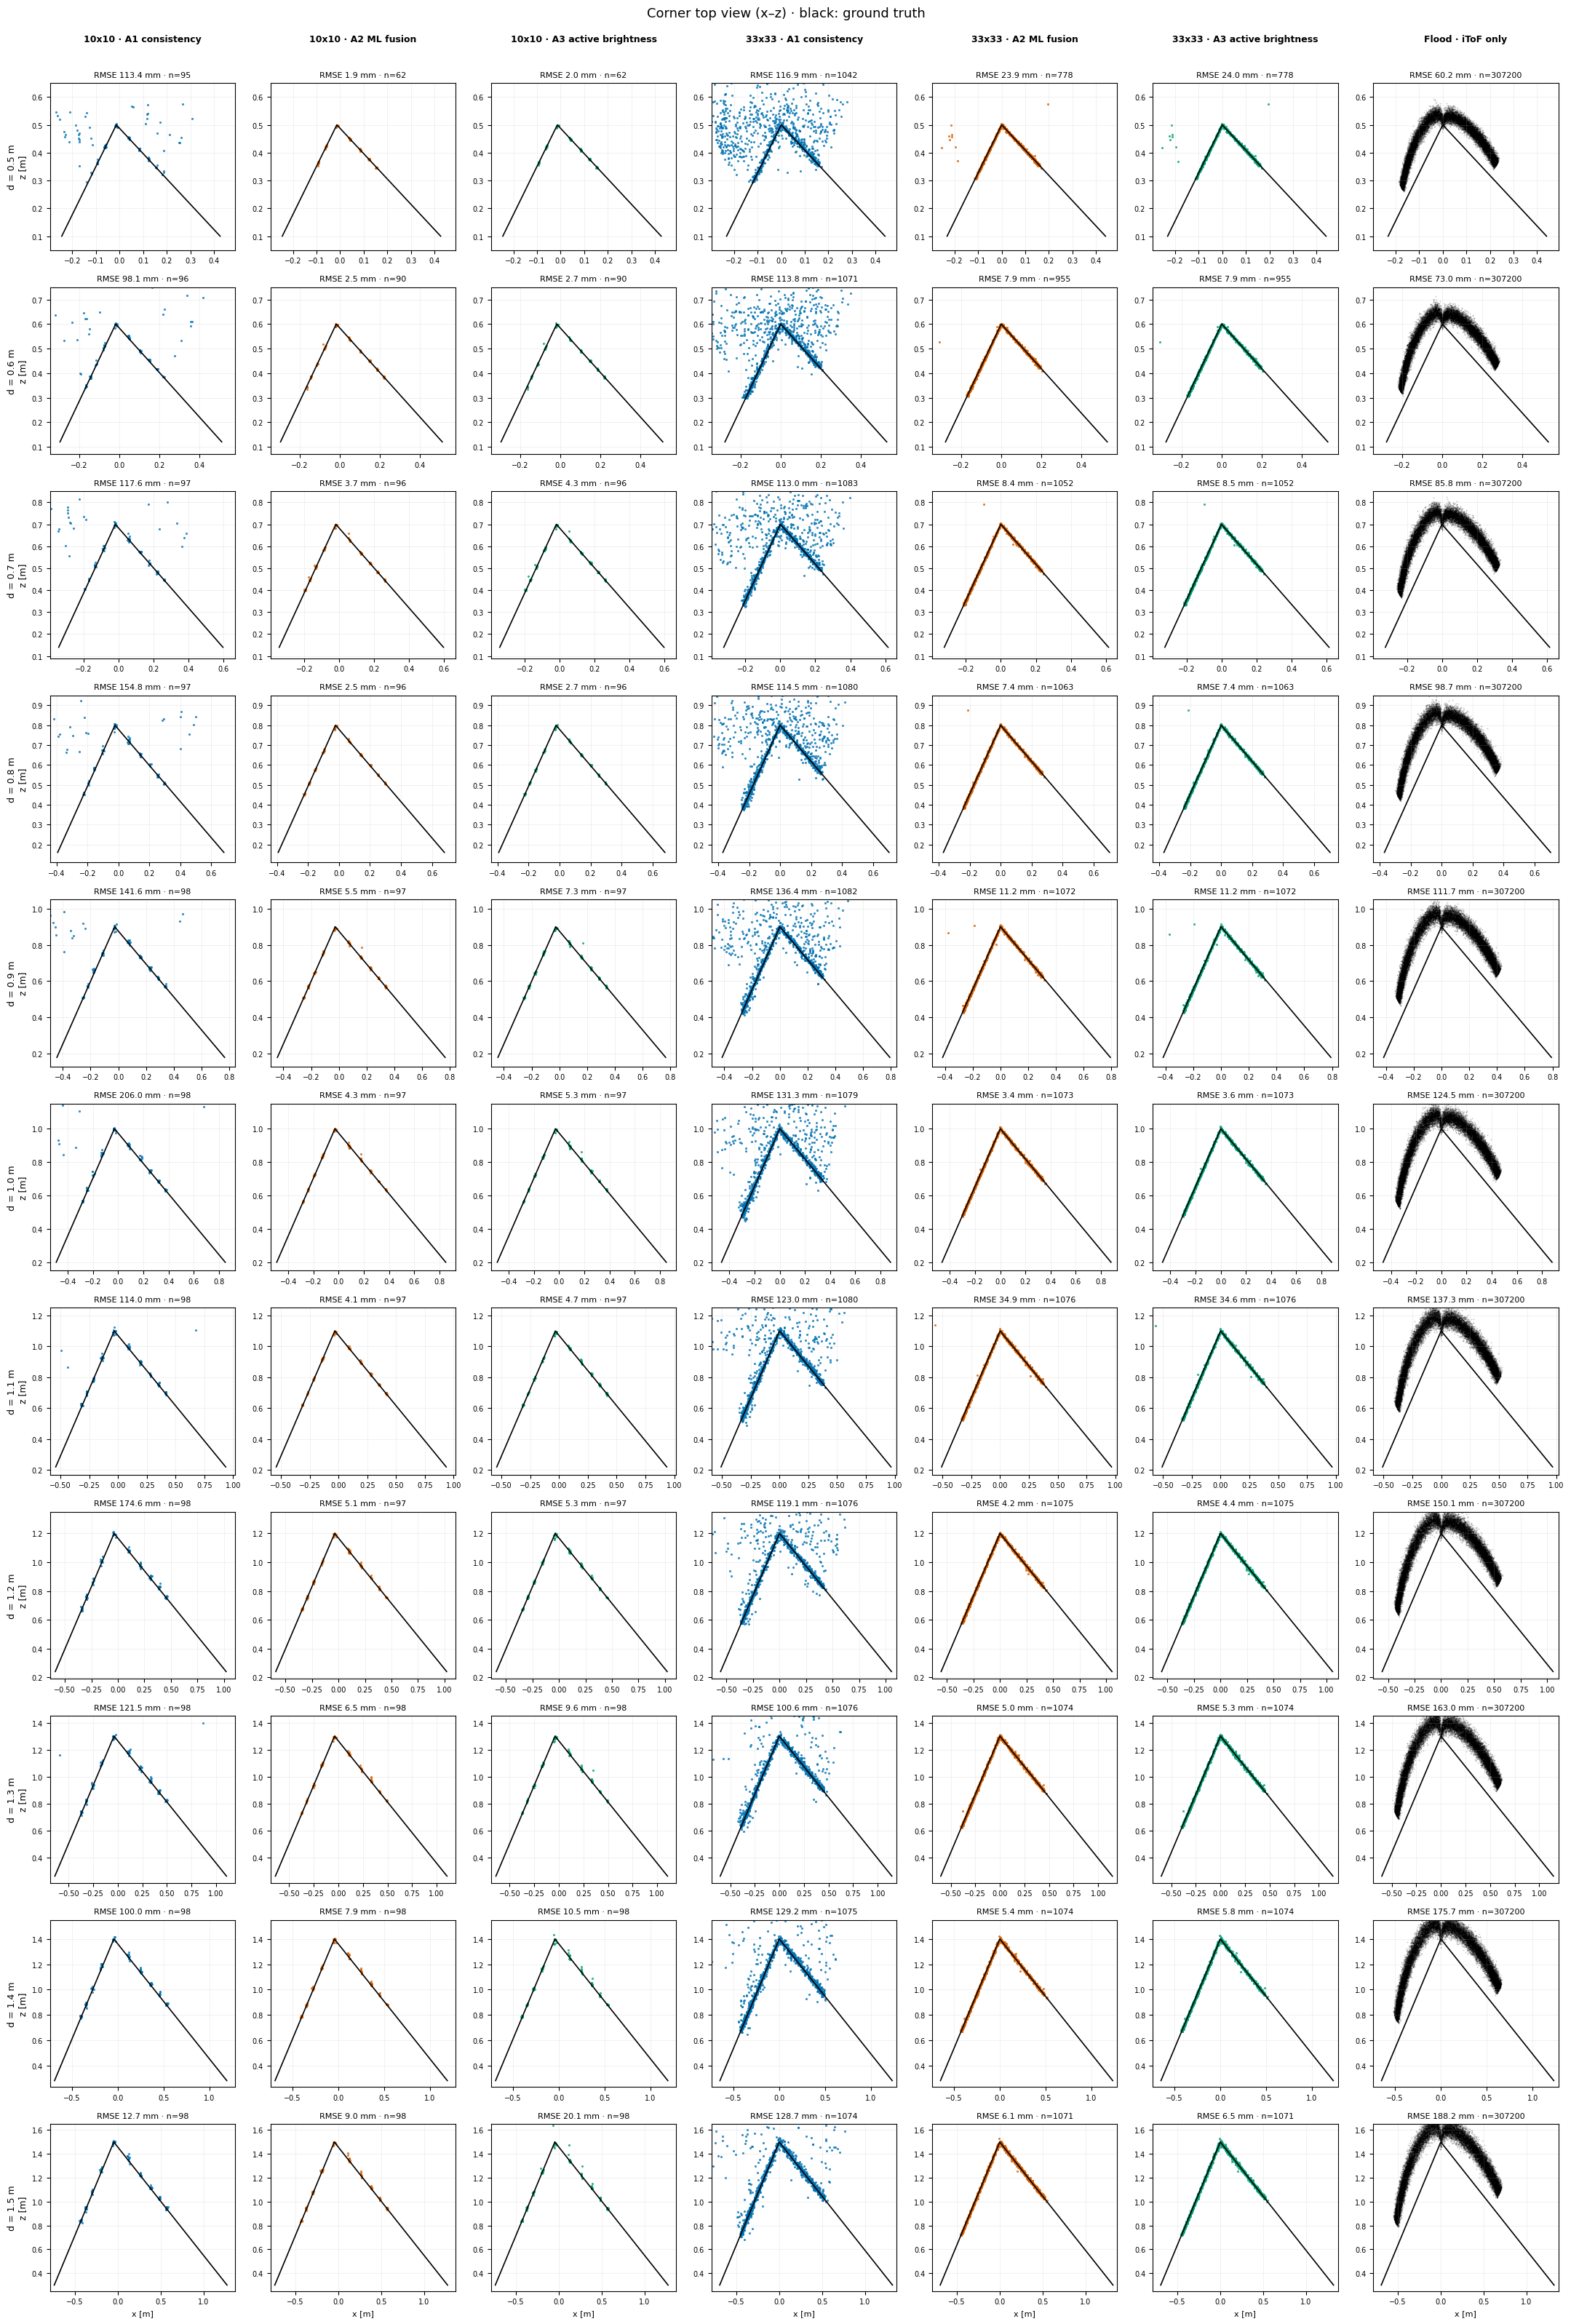

In [8]:
# Okabe–Ito, same assignment as noiseEstimation.ipynb: a colour always means the same approach.
A_COLOR = {1: "#0072B2", 2: "#D55E00", 3: "#009E73", "ToF": "#000000"}
A_NAME = {1: "A1 consistency", 2: "A2 ML fusion", 3: "A3 active brightness", "ToF": "iToF only"}
COLUMNS = [(pat, a) for pat in PATTERNS for a in (1, 2, 3)] + [(FLOOD, "ToF")]
COL_LABEL = {**{(pat, a): f"{PATTERNS[pat]['label']} · {A_NAME[a]}" for pat in PATTERNS for a in (1, 2, 3)},
             (FLOOD, "ToF"): "Flood · iToF only"}
FLOOD_PLOT_MAX = 20000        # flood points drawn per panel (random subset)
_rng = np.random.default_rng(0)


def series_stats(series, a, d):
    pts = SWEEP[(series, a)][d]
    if len(pts) == 0:
        return pts, np.nan
    err = dist_to_gt(pts[:, 0], pts[:, 2], CORNERS[(series, d)])
    return pts, float(np.sqrt(np.mean(err ** 2)))


fig, axs = plt.subplots(len(DISTS), len(COLUMNS), figsize=(3.1 * len(COLUMNS), 2.9 * len(DISTS)),
                        squeeze=False)
for i, d in enumerate(DISTS):
    c_all = np.vstack([CORNERS[(s, d)] for s, _ in COLUMNS])
    xlim = (c_all[:, 0].min() - 0.05, c_all[:, 0].max() + 0.05)
    zlim = (c_all[:, 1].min() - 0.05, d + 0.15)
    for j, (series, a) in enumerate(COLUMNS):
        ax = axs[i, j]
        pts, rmse = series_stats(series, a, d)
        if series == FLOOD and len(pts) > FLOOD_PLOT_MAX:
            pts = pts[_rng.choice(len(pts), FLOOD_PLOT_MAX, replace=False)]
        ax.scatter(pts[:, 0], pts[:, 2], s=1.5 if series == FLOOD else 5, lw=0,
                   c=A_COLOR[a], alpha=0.25 if series == FLOOD else 0.8)
        c = CORNERS[(series, d)]
        ax.plot(c[:, 0], c[:, 1], "k-", lw=1.2)
        ax.set_xlim(xlim); ax.set_ylim(zlim)
        ax.set_title(f"RMSE {rmse * 1e3:.1f} mm · n={len(SWEEP[(series, a)][d])}", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.25, lw=0.5)
        if i == 0:
            ax.annotate(COL_LABEL[(series, a)], (0.5, 1.25), xycoords="axes fraction",
                        ha="center", fontsize=9, fontweight="bold")
        if j == 0:
            ax.set_ylabel(f"d = {d:.1f} m\nz [m]", fontsize=9)
        if i == len(DISTS) - 1:
            ax.set_xlabel("x [m]", fontsize=8)
fig.suptitle("Corner top view (x–z) · black: ground truth", y=1.0, fontsize=13)
fig.tight_layout()
plt.show()

## Result 2 — profile across the fold

Depth error against the GT corner, z − z_GT(x), over the lateral position relative to the
fold. A correctly reproduced kink is a flat band around 0 right up to the fold; multipath
shows up as a bump that grows towards the fold (the corner turns into a curve).
For the flood cloud the black line is the median per 1 cm bin.

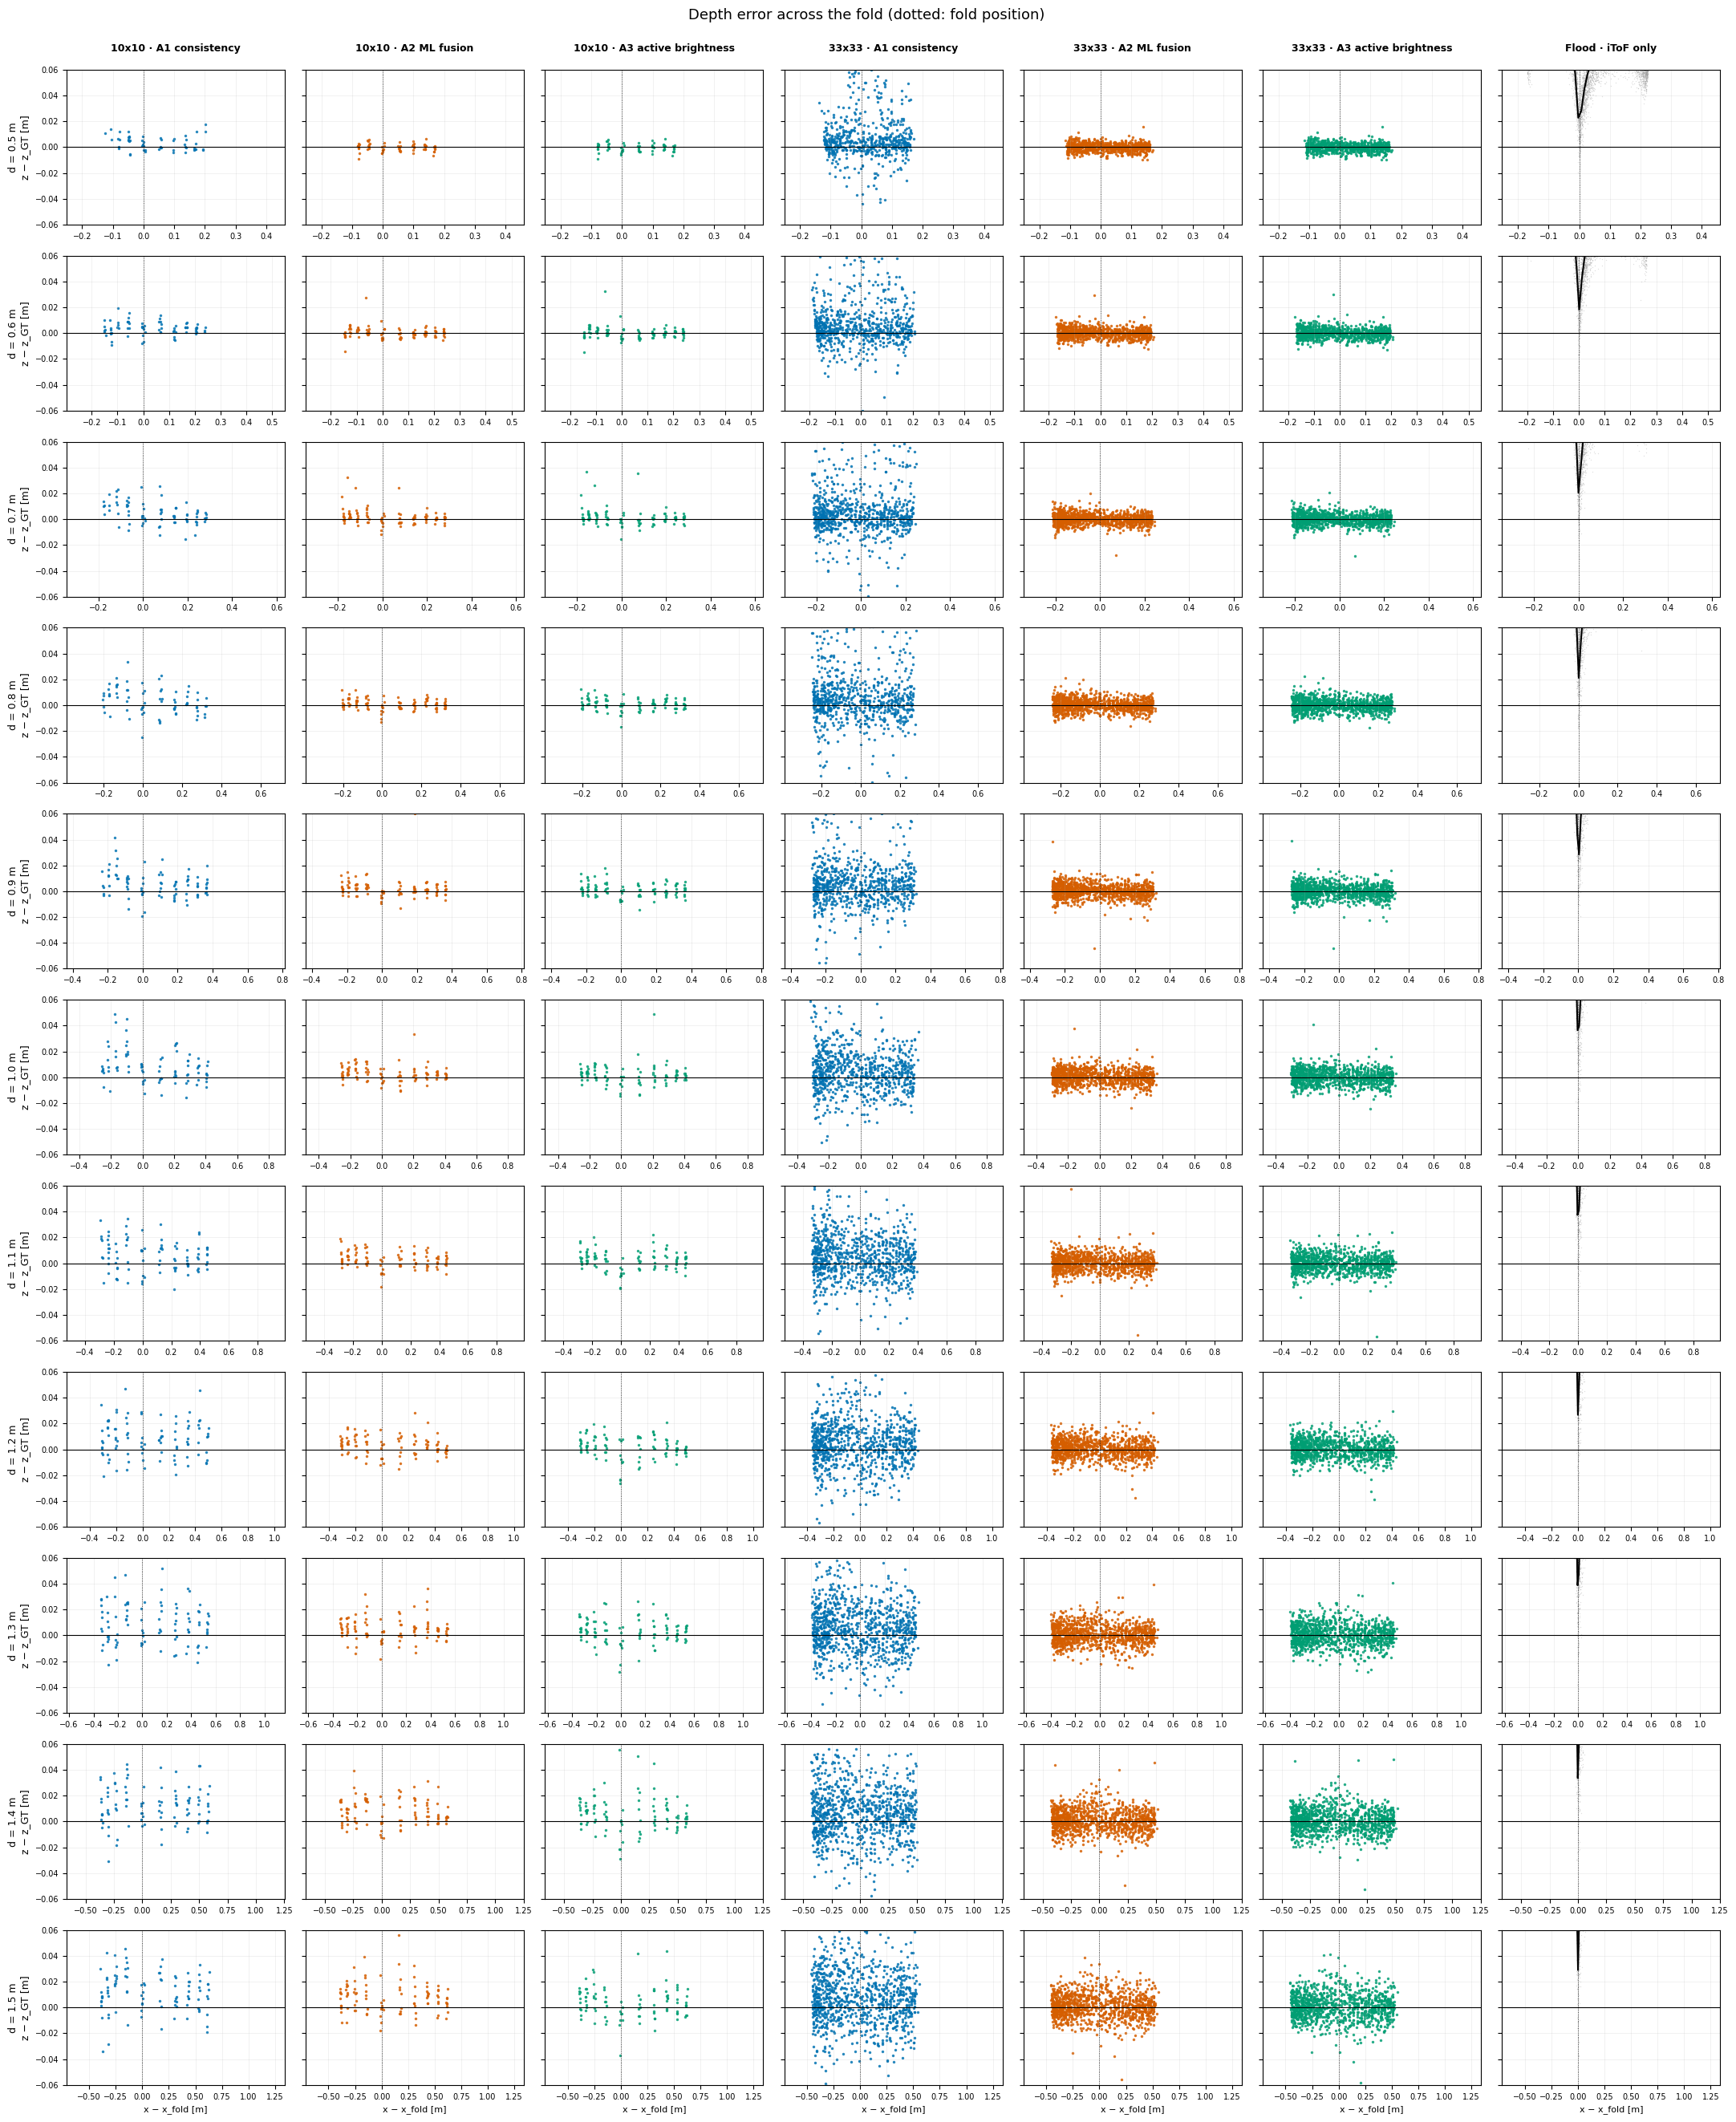

In [9]:
PROFILE_YLIM = 0.06   # ±[m]
fig, axs = plt.subplots(len(DISTS), len(COLUMNS), figsize=(3.1 * len(COLUMNS), 2.4 * len(DISTS)),
                        squeeze=False, sharey=True)
for i, d in enumerate(DISTS):
    for j, (series, a) in enumerate(COLUMNS):
        ax = axs[i, j]
        c = CORNERS[(series, d)]
        pts = SWEEP[(series, a)][d]
        x_rel = pts[:, 0] - c[1, 0]
        dz = pts[:, 2] - z_gt(pts[:, 0], c)
        if series == FLOOD:
            sub = _rng.choice(len(pts), min(len(pts), FLOOD_PLOT_MAX), replace=False)
            ax.scatter(x_rel[sub], dz[sub], s=1, lw=0, c="0.6", alpha=0.3)
            bins = np.arange(x_rel.min(), x_rel.max() + 0.01, 0.01)
            idx = np.digitize(x_rel, bins)
            med = [np.nanmedian(dz[idx == k]) if np.sum(np.isfinite(dz[idx == k])) > 20 else np.nan
                   for k in range(1, len(bins))]
            ax.plot(bins[:-1] + 0.005, med, "k-", lw=1.5)
        else:
            ax.scatter(x_rel, dz, s=6, lw=0, c=A_COLOR[a], alpha=0.85)
        ax.axhline(0, color="k", lw=0.8)
        ax.axvline(0, color="k", lw=0.6, ls=":")
        ax.set_ylim(-PROFILE_YLIM, PROFILE_YLIM)
        ax.set_xlim(c[0, 0] - c[1, 0] - 0.02, c[2, 0] - c[1, 0] + 0.02)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.25, lw=0.5)
        if i == 0:
            ax.annotate(COL_LABEL[(series, a)], (0.5, 1.12), xycoords="axes fraction",
                        ha="center", fontsize=9, fontweight="bold")
        if j == 0:
            ax.set_ylabel(f"d = {d:.1f} m\nz − z_GT [m]", fontsize=9)
        if i == len(DISTS) - 1:
            ax.set_xlabel("x − x_fold [m]", fontsize=8)
fig.suptitle("Depth error across the fold (dotted: fold position)", y=1.0, fontsize=13)
fig.tight_layout()
plt.show()

## Result 3 — summary over distance

(a) RMSE of the perpendicular distance to the GT walls, (b) mean signed depth error in the
fold region (|x − x_fold| < `FOLD_HALF_WIDTH`) — the size of the multipath bump, (c) valid
dots per approach as a share of the calibrated trails (flood: share of pixels with a return).
10x10 solid, 33x33 dashed, flood black.

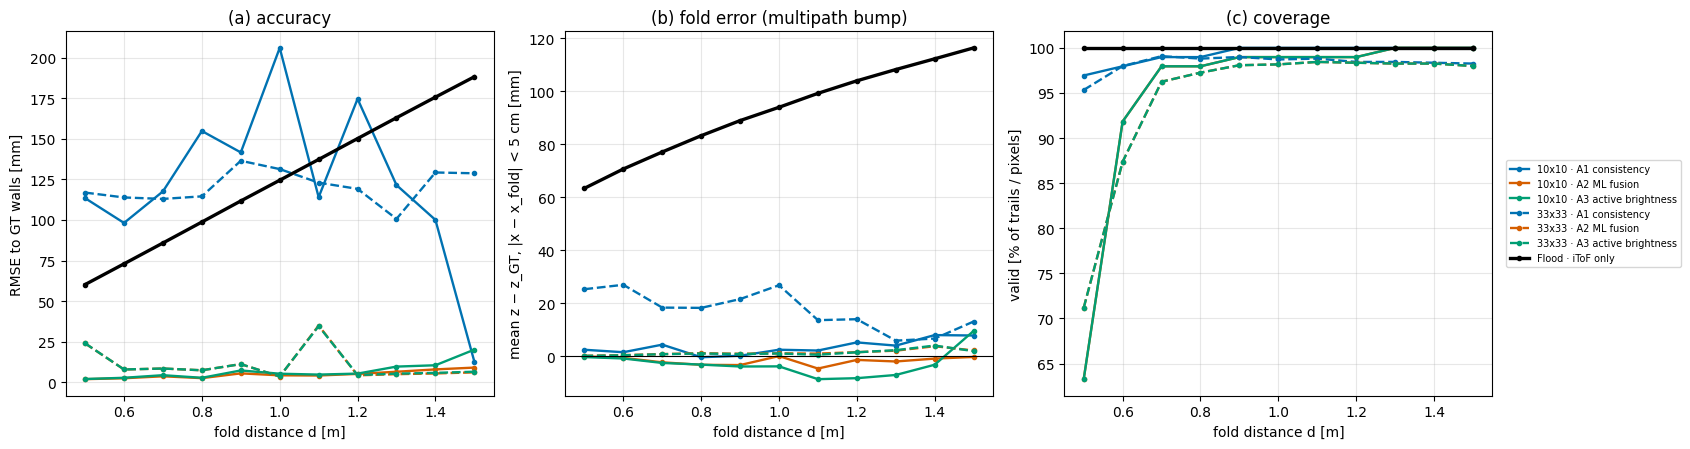

series                           0.5     0.6     0.7     0.8     0.9     1.0     1.1     1.2     1.3     1.4     1.5   (RMSE [mm] / fold error [mm])
10x10 · A1 consistency         113.4    98.1   117.6   154.8   141.6   206.0   114.0   174.6   121.5   100.0    12.7
                                +2.4    +1.5    +4.3    -0.4    +0.1    +2.4    +2.1    +5.2    +4.0    +7.9    +7.8
10x10 · A2 ML fusion             1.9     2.5     3.7     2.5     5.5     4.3     4.1     5.1     6.5     7.9     9.0
                                -0.1    -0.7    -2.3    -3.3    -3.4    +0.0    -4.7    -1.4    -2.0    -0.9    -0.3
10x10 · A3 active brightness     2.0     2.7     4.3     2.7     7.3     5.3     4.7     5.3     9.6    10.5    20.1
                                -0.4    -0.9    -2.6    -3.2    -3.9    -3.9    -8.7    -8.3    -7.1    -3.2    +9.5
33x33 · A1 consistency         116.9   113.8   113.0   114.5   136.4   131.3   123.0   119.1   100.6   129.2   128.7
                               +

In [10]:
FOLD_HALF_WIDTH = 0.05   # [m]

rows = []
for series, a in COLUMNS:
    for d in DISTS:
        pts, rmse = series_stats(series, a, d)
        c = CORNERS[(series, d)]
        near = np.abs(pts[:, 0] - c[1, 0]) < FOLD_HALF_WIDTH if len(pts) else np.zeros(0, bool)
        fold_err = float(np.mean(pts[near, 2] - z_gt(pts[near, 0], c))) if near.any() else np.nan
        n_ref = N_TRAILS.get(series, 640 * 480)
        rows.append((series, a, d, rmse, fold_err, len(pts) / n_ref, int(near.sum())))
rows_arr = np.array([(r[2], r[3], r[4], r[5]) for r in rows], float)

fig, axs = plt.subplots(1, 3, figsize=(17, 4.6))
for series, a in COLUMNS:
    sel = [k for k, r in enumerate(rows) if r[0] == series and r[1] == a]
    ls = "-" if series == "Schmersal10_y" else ("--" if series == "Schmersal30_y" else "-")
    lw = 2.4 if series == FLOOD else 1.7
    for ax, col, scale in zip(axs, (1, 2, 3), (1e3, 1e3, 100)):
        ax.plot(rows_arr[sel, 0], rows_arr[sel, col] * scale, ls, color=A_COLOR[a], lw=lw,
                marker="o", ms=3, label=COL_LABEL[(series, a)])
axs[0].set_ylabel("RMSE to GT walls [mm]")
axs[1].set_ylabel(f"mean z − z_GT, |x − x_fold| < {FOLD_HALF_WIDTH * 100:.0f} cm [mm]")
axs[1].axhline(0, color="k", lw=0.8)
axs[2].set_ylabel("valid [% of trails / pixels]")
for ax, t in zip(axs, ("(a) accuracy", "(b) fold error (multipath bump)", "(c) coverage")):
    ax.set_xlabel("fold distance d [m]")
    ax.set_title(t)
    ax.grid(alpha=0.3)
axs[2].legend(fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plt.show()

print(f"{'series':28s}" + "".join(f"{d:>8.1f}" for d in DISTS) + "   (RMSE [mm] / fold error [mm])")
for series, a in COLUMNS:
    sel = [r for r in rows if r[0] == series and r[1] == a]
    print(f"{COL_LABEL[(series, a)]:28s}" + "".join(f"{r[3] * 1e3:8.1f}" for r in sel))
    print(f"{'':28s}" + "".join(f"{r[4] * 1e3:+8.1f}" for r in sel))

## Notes

- Flood: one `laser` with 110° opening at the camera, 0.5 W, 12 ms, 1024 spp (the indirect
  light is Monte-Carlo noise; at 1024 spp the mean depth at the fold is converged to
  < 0.2 mm). Generated from the `Schmersal30_y` MPI scenes, so its corner is identical
  to the 33x33 one.
- Dot MPI scenes: 10x10 rendered at 256 spp (ToF) / 128 spp (SL), 33x33 at 1024 spp.
- Coherent pattern: one duplicated dot direction at the right image edge (see calibration).
- ToF light-path correction (`LIGHT_PATH_CORRECTION`): on for the dot patterns, whose ToF is
  lit from the projector at B; off for the flood series (light at the camera). Calibrations
  and caches carry `LPC_TAG`, so the uncorrected run stays available.
- The approaches' global settings (`EPS_THRESHOLD`, peak finding, …) are the defaults of
  `approaches.py`, unchanged.